## Objective

This notebook demonstrates a **modern equity research workflow** using **real APIs**:

1. Pull **market prices** and **company fundamentals** via APIs  
2. Clean and align financial time series  
3. Compute valuation, quality, and growth metrics  
4. Perform a simple internal screening assessment  
5. Prepare inputs for valuation (DCF preview)



Company: **Adobe Inc. (ADBE)**  
Fundamentals API: **Alpha Vantage**  
Prices API: **Alpha Vantage**

### 2 - Environment & Import

In [1]:
import sys
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.13.2 (v3.13.2:4f8bb3947cf, Feb  4 2025, 11:51:10) [Clang 15.0.0 (clang-1500.3.9.4)]
pandas: 2.2.3
numpy: 2.2.3


### 3- Configuraion

In [7]:
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

### 4- Parameters & API Setup

In [8]:
#Define a variable 
ALPHAVANTAGE_API_KEY = "38OHJZVBDDUDMDKV"
TICKER = "ADBE"

### 5- Alpha Vantage API Helper

   

In [10]:
#Instead of writing a long URL, you break it down like this

ALPHA_BASE = "https://www.alphavantage.co/query"

def av_fetch(params):
    params["apikey"] = ALPHAVANTAGE_API_KEY
    r = requests.get(ALPHA_BASE, params=params)
    r.raise_for_status()
    return r.json()

### 6- Load Market Prices (monthly)

In [ ]:
#This gives us a JSON file, and then we need to conver it to a pandas Dataframe.

price_raw = av_fetch({
    "function": "TIME_SERIES_MONTHLY_ADJUSTED",
    "symbol": TICKER
})

prices = (
    pd.DataFrame(price_raw["Monthly Adjusted Time Series"])
      .T
      .astype(float)
)

#Do some sorting then. 

prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

prices["Return"] = prices["5. adjusted close"].pct_change()
prices.tail()

,1. open,2. high,3. low,4. close,5. adjusted close,6. volume,7. dividend amount,Return
2025-12-31,316.3900,362.7100,316.1100,349.9900,349.9900,94660689.0000,0.0000,0.0933
2026-01-30,350.6750,351.1200,284.6000,293.2500,293.2500,100305055.0000,0.0000,-0.1621
2026-02-27,297.0100,299.3800,244.2800,262.4100,262.4100,119195998.0000,0.0000,-0.1052
2026-03-31,257.6000,285.3600,233.1550,243.0800,243.0800,141420317.0000,0.0000,-0.0737
2026-04-20,241.9600,254.5100,224.1300,248.6300,248.6300,63984648.0000,0.0000,0.0228


### 7- Load Fundamentals - Income Statement

In [11]:
income_raw = av_fetch({
    "function": "INCOME_STATEMENT",
    "symbol": TICKER
})

income = pd.DataFrame(income_raw["annualReports"])

# Convert date column safely
income["date"] = pd.to_datetime(income["fiscalDateEnding"])
income = income.set_index("date").sort_index()

# Convert all non-text columns to numeric (robust to "None")
for col in income.columns:
    if col not in ["fiscalDateEnding", "reportedCurrency"]:
        income[col] = pd.to_numeric(income[col], errors="coerce")

income.tail()

,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,...,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome
date,,,,,,,,,,,,,,,,,,,,,
2021-11-30,2021-11-30,USD,13920000000,15785000000,1865000000,1865000000,5802000000,1085000000,2540000000,8118000000,...,NaN,861000000,5705000000,883000000,NaN,4822000000.0000,NaN,5814000000,6675000000,4822000000
2022-11-30,2022-11-30,USD,15441000000,17606000000,2165000000,2165000000,6098000000,1219000000,2987000000,9343000000,...,NaN,939000000,6008000000,1252000000,NaN,4756000000.0000,NaN,6116000000,7055000000,4756000000
2023-11-30,2023-11-30,USD,17055000000,19409000000,2354000000,2354000000,6650000000,1413000000,3473000000,10405000000,...,NaN,872000000,6799000000,1371000000,NaN,5428000000.0000,NaN,6912000000,7784000000,5428000000
2024-11-30,2024-11-30,USD,19147000000,21505000000,2358000000,2358000000,6741000000,1529000000,3944000000,12406000000,...,NaN,857000000,6931000000,1371000000,NaN,5560000000.0000,NaN,7100000000,7957000000,5560000000
2025-11-30,2025-11-30,USD,21061000000,23769000000,2708000000,2708000000,8706000000,1573000000,4294000000,12355000000,...,NaN,818000000,8734000000,1604000000,NaN,7130000000.0000,NaN,8931000000,9749000000,7130000000


### 8- Load Balance Sheet

In [13]:
balance_raw = av_fetch({
    "function": "BALANCE_SHEET",
    "symbol": TICKER
})

balance = pd.DataFrame(balance_raw["annualReports"])


# Convert date column safely
balance["date"] = pd.to_datetime(balance["fiscalDateEnding"])
balance = balance.set_index("date").sort_index()

# Convert all non-text columns to numeric (robust to "None")
for col in balance.columns:
    if col not in ["fiscalDateEnding", "reportedCurrency"]:
        balance[col] = pd.to_numeric(balance[col], errors="coerce")

balance.tail()


,fiscalDateEnding,reportedCurrency,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,cashAndShortTermInvestments,inventory,currentNetReceivables,totalNonCurrentAssets,propertyPlantEquipment,...,currentLongTermDebt,longTermDebtNoncurrent,shortLongTermDebtTotal,otherCurrentLiabilities,otherNonCurrentLiabilities,totalShareholderEquity,treasuryStock,retainedEarnings,commonStock,commonStockSharesOutstanding
date,,,,,,,,,,,,,,,,,,,,,
2021-11-30,2021-11-30,USD,27241000000,8669000000,3844000000,3844000000,NaN,1878000000,18572000000,2116000000.0000,...,NaN,NaN,4673000000.0000,1736000000,252000000.0000,14797000000,-17399000000.0000,23905000000,NaN,481000000
2022-11-30,2022-11-30,USD,27165000000,8996000000,4236000000,4236000000,NaN,2065000000,18169000000,1908000000.0000,...,500000000.0000,NaN,4633000000.0000,1790000000,265000000.0000,14051000000,-23843000000.0000,28319000000,NaN,471000000
2023-11-30,2023-11-30,USD,29779000000,11084000000,7141000000,7141000000,NaN,2224000000,18695000000,NaN,...,NaN,NaN,4080000000.0000,1942000000,376000000.0000,16518000000,NaN,33346000000,NaN,459000000
2024-11-30,2024-11-30,USD,30230000000,11232000000,7613000000,7613000000,NaN,2072000000,18998000000,NaN,...,1499000000.0000,NaN,6056000000.0000,2215000000,446000000.0000,14105000000,NaN,38470000000,NaN,450000000
2025-11-30,2025-11-30,USD,29496000000,10163000000,5431000000,5431000000,NaN,2344000000,19333000000,NaN,...,NaN,NaN,6648000000.0000,2648000000,508000000.0000,11623000000,NaN,45354000000,NaN,427000000


### 9- Cash Flow Statement

In [14]:
cashflow_raw = av_fetch({
    "function": "CASH_FLOW",
    "symbol": TICKER
})

cashflow = pd.DataFrame(cashflow_raw["annualReports"])

# Convert date column safely
cashflow["date"] = pd.to_datetime(cashflow["fiscalDateEnding"])
cashflow = cashflow.set_index("date").sort_index()

# Convert all non-text columns to numeric (robust to "None")
for col in cashflow.columns:
    if col not in ["fiscalDateEnding", "reportedCurrency"]:
        cashflow[col] = pd.to_numeric(cashflow[col], errors="coerce")

cashflow.tail()



,fiscalDateEnding,reportedCurrency,operatingCashflow,paymentsForOperatingActivities,proceedsFromOperatingActivities,changeInOperatingLiabilities,changeInOperatingAssets,depreciationDepletionAndAmortization,capitalExpenditures,changeInReceivables,...,dividendPayoutPreferredStock,proceedsFromIssuanceOfCommonStock,proceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet,proceedsFromIssuanceOfPreferredStock,proceedsFromRepurchaseOfEquity,proceedsFromSaleOfTreasuryStock,stockBasedCompensation,changeInCashAndCashEquivalents,changeInExchangeRate,netIncome
date,,,,,,,,,,,,,,,,,,,,,
2021-11-30,2021-11-30,USD,7230000000,NaN,NaN,NaN,NaN,788000000,330000000,-430000000.0000,...,NaN,NaN,NaN,NaN,-3950000000,NaN,1069000000,-634000000.0000,-26000000.0000,4822000000
2022-11-30,2022-11-30,USD,7838000000,NaN,NaN,NaN,NaN,856000000,442000000,-198000000.0000,...,NaN,NaN,NaN,NaN,-6550000000,NaN,1440000000,443000000.0000,NaN,4756000000
2023-11-30,2023-11-30,USD,7302000000,NaN,NaN,NaN,NaN,872000000,360000000,NaN,...,NaN,NaN,NaN,NaN,-4400000000,NaN,1718000000,NaN,NaN,5428000000
2024-11-30,2024-11-30,USD,8056000000,NaN,NaN,NaN,NaN,894000000,232000000,NaN,...,NaN,NaN,NaN,NaN,-9500000000,NaN,1881000000,NaN,NaN,5560000000
2025-11-30,2025-11-30,USD,10031000000,NaN,NaN,NaN,NaN,818000000,179000000,NaN,...,NaN,NaN,NaN,NaN,-11281000000,NaN,1942000000,NaN,NaN,7130000000


###  10 - Core Financial Ratios

In [15]:
ratios = pd.DataFrame(index=income.index)

# Valuation proxies (illustrative — market cap comes from prices later)
ratios["Revenue"] = income["totalRevenue"]
ratios["Operating Income"] = income["operatingIncome"]
ratios["Net Income"] = income["netIncome"]

# Margins
ratios["Gross Margin"] = income["grossProfit"] / income["totalRevenue"]
ratios["Operating Margin"] = income["operatingIncome"] / income["totalRevenue"]

# Growth
ratios["Revenue Growth"] = income["totalRevenue"].pct_change()
ratios["NI Growth"] = income["netIncome"].pct_change()

ratios.tail()

,Revenue,Operating Income,Net Income,Gross Margin,Operating Margin,Revenue Growth,NI Growth
date,,,,,,,
2021-11-30,15785000000,5802000000,4822000000,0.8818,0.3676,0.2267,-0.0833
2022-11-30,17606000000,6098000000,4756000000,0.8770,0.3464,0.1154,-0.0137
2023-11-30,19409000000,6650000000,5428000000,0.8787,0.3426,0.1024,0.1413
2024-11-30,21505000000,6741000000,5560000000,0.8904,0.3135,0.1080,0.0243
2025-11-30,23769000000,8706000000,7130000000,0.8861,0.3663,0.1053,0.2824


## Analysis

### 1 - Simple Internal Screening Score

In [16]:
screen = pd.DataFrame(index=ratios.index)

screen["QualityScore"] = (
    ratios["Operating Margin"].rank()
)

screen["GrowthScore"] = (
    ratios["Revenue Growth"].rank()
)

screen["TotalScore"] = screen["QualityScore"] + screen["GrowthScore"]
screen.sort_values("TotalScore", ascending=False).head()

,QualityScore,GrowthScore,TotalScore
date,,,
2021-11-30,20.0000,15.0000,35.0000
2017-11-30,13.0000,18.0000,31.0000
2018-11-30,15.0000,16.0000,31.0000
2019-11-30,12.0000,17.0000,29.0000
2022-11-30,18.0000,9.0000,27.0000


### 2- Visual Diagnostics
Wealth Index

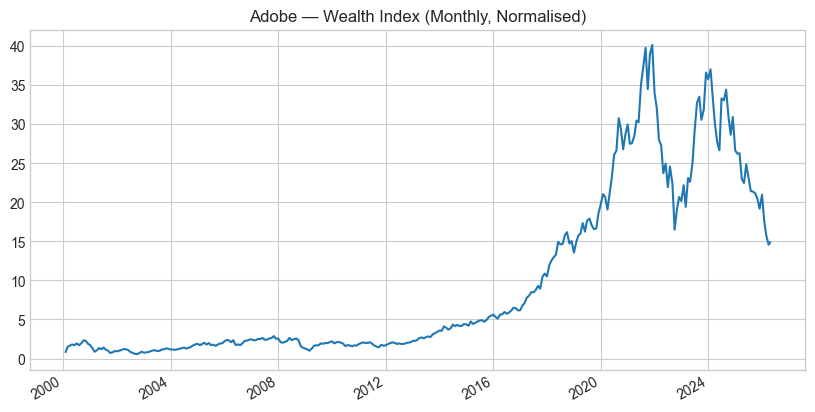

In [17]:
wealth = (1 + prices["Return"].dropna()).cumprod()

wealth.plot(
    title="Adobe — Wealth Index (Monthly, Normalised)",
    figsize=(10,5)
)
plt.show()

Revenue & Margin Evolution

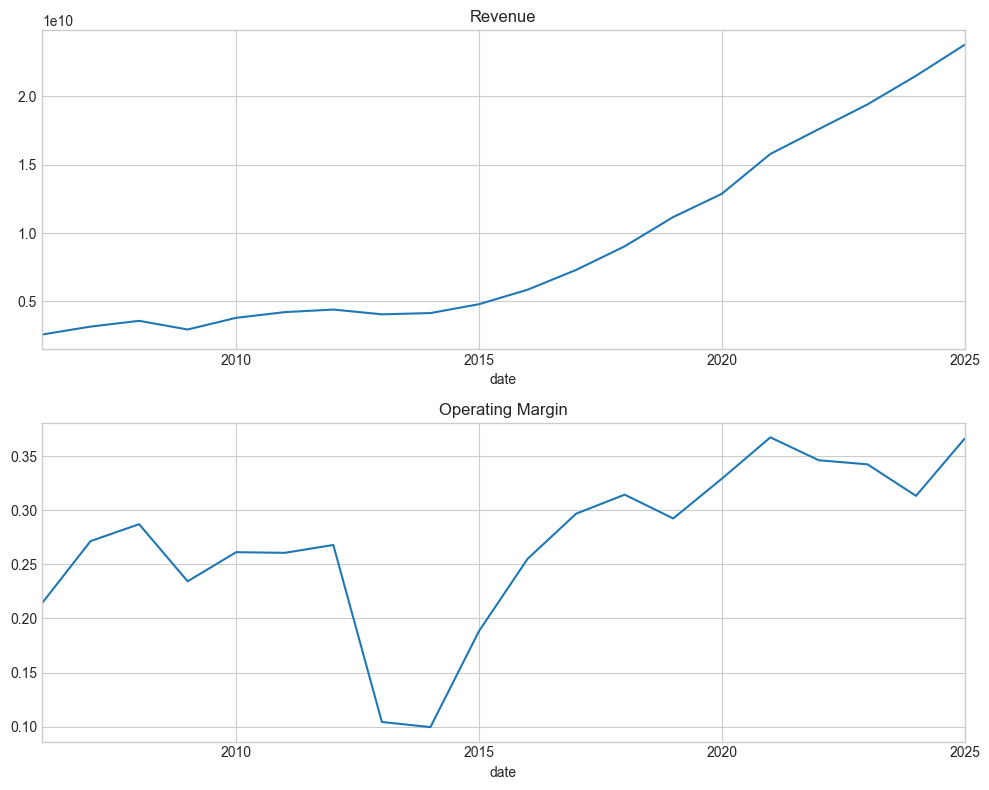

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))

income["totalRevenue"].plot(ax=ax[0], title="Revenue")
ratios["Operating Margin"].plot(ax=ax[1], title="Operating Margin")

plt.tight_layout()
plt.show()

### 3- Mini-DCF Prepararatin 

In [ ]:
#Create a reusable function. We change the ticker. We get a different company? 

latest = income.index.max()

revenue_latest = income.loc[latest, "totalRevenue"]
ebit_latest = income.loc[latest, "operatingIncome"]
fcf_latest = cashflow.loc[latest, "operatingCashflow"] - cashflow.loc[latest, "capitalExpenditures"]

print("Latest Revenue:", revenue_latest)
print("Latest EBIT:", ebit_latest)
print("Latest FCF (approx):", fcf_latest)

Latest Revenue: 23769000000
Latest EBIT: 8706000000
Latest FCF (approx): 9852000000


 ### 4- Research Note (Student Output Template)


## Mini Research Note — Adobe Inc. (ADBE)

**Business Overview:**  
Adobe operates a subscription-based digital media and document platform.

**Quality:**  
High and stable operating margins indicate strong pricing power.

**Growth:**  
Consistent revenue expansion driven by SaaS adoption.

**Risks:**  
- Increased competition (AI‑based design tools)  
- Enterprise IT spending cycles  

**Conclusion:**  
Adobe represents a high‑quality compounder trading at a valuation premium.